# Build Species Co-occurrence Networks

Reads `observations_extended.csv` and builds **two kinds** of networks:

1. **Annual network** - only calendar year 2025 (Jan–Dec). 

2. **5 seasonal networks** — full extended timeline (Dec 2024 → Feb 2026).
```
observations_extended.csv (Dec 2024 → Feb 2026, ~681k obs)
│
├─ annual.graphml         ← Jan–Dec 2025 only
│
├─ winter_0.graphml       ← Dec 2024 + Jan–Feb 2025
├─ spring.graphml         ← Mar–May 2025
├─ summer.graphml         ← Jun–Aug 2025
├─ autumn.graphml         ← Sep–Nov 2025
└─ winter_1.graphml       ← Dec 2025 + Jan–Feb 2026
```


In [ ]:
# ── Repository root ───────────────────────────────────────────────────────────
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name in ('notebooks', 'legacy') else Path.cwd()
assert (ROOT / 'data').is_dir(), f'Repository root not found from {Path.cwd()}'

## Parameters


In [ ]:
MIN_OBS = 3              # species with fewer obs are removed
MIN_COOCCURRENCE = 2     # edges require co-occurrence in ≥2 cells
GRID_SIZE = 0.1         

DATA_DIR = ROOT / "data" / "raw"
NETWORKS_DIR = ROOT / "data" / "networks"
FIGURES_DIR = ROOT / "figures"

SEASONS = ["winter_0", "spring", "summer", "autumn", "winter_1"]
SEASON_NAMES = {
    "winter_0": "Winter₀", "spring": "Spring", "summer": "Summer",
    "autumn": "Autumn", "winter_1": "Winter₁",
}


## Imports


In [2]:
import os, json, math
from itertools import combinations
from collections import defaultdict, Counter
from datetime import datetime

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

os.makedirs(NETWORKS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style="ticks", context="paper", font_scale=1.1, rc={
    "font.family": "serif", "axes.linewidth": 0.7,
    "grid.linewidth": 0.4, "grid.alpha": 0.3,
})

SEASON_PAL = {
    "annual": "#333333",
    "winter_0": "#5B8EB8", "spring": "#7FB069", "summer": "#E0A040",
    "autumn": "#C7563C", "winter_1": "#5B8EB8",
}

def savefig(fig, name):
    fig.savefig(f"{FIGURES_DIR}/{name}.png", dpi=300, bbox_inches="tight", pad_inches=0.05)
    fig.savefig(f"{FIGURES_DIR}/{name}.pdf", bbox_inches="tight", pad_inches=0.05)
    print(f"  💾 {FIGURES_DIR}/{name}.png + .pdf")

print("Ready.")


Ready.


## Load data and filter rare species

Reads the extended dataset, applies MIN_OBS filter, then creates two
subsets: `obs_annual` (2025 only) and the full `obs_df` (for seasonal).


In [ ]:
OBS_FILE = DATA_DIR / "observations_extended.csv.gz"
SPECIES_FILE = DATA_DIR / "species.csv.gz"

print("Loading data...")
obs_all = pd.read_csv(OBS_FILE)
species_df = pd.read_csv(SPECIES_FILE)

print(f"  Raw observations: {len(obs_all):,}")
print(f"  Raw species:      {obs_all['taxon_id'].nunique():,}")
print(f"  Date range:       {obs_all['observed_on'].min()} → {obs_all['observed_on'].max()}")

# Filter rare species 
species_counts = obs_all["taxon_id"].value_counts()
valid_species = species_counts[species_counts >= MIN_OBS].index
obs_df = obs_all[obs_all["taxon_id"].isin(valid_species)].copy()

n_removed = obs_all["taxon_id"].nunique() - obs_df["taxon_id"].nunique()
print(f"\n  After MIN_OBS={MIN_OBS}: {obs_df['taxon_id'].nunique():,} species "
      f"({len(obs_df):,} obs) — removed {n_removed:,} rare species")

# ── ANNUAL subset: only calendar year 2025 ──
obs_annual = obs_df[obs_df["observed_on"].str.startswith("2025")].copy()
print(f"\n  Annual (2025 only): {len(obs_annual):,} obs, "
      f"{obs_annual['taxon_id'].nunique():,} species")

# ── SEASONAL: full extended timeline ──
print(f"  Seasonal (full extended timeline):")
for s in SEASONS:
    sub = obs_df[obs_df["season"] == s]
    print(f"    {SEASON_NAMES[s]:<10s}  {len(sub):>8,} obs  {sub['taxon_id'].nunique():>6,} species")


Loading data...
  Raw observations: 681,813
  Raw species:      12,592
  Date range:       2024-12-01 → 2026-02-28

  After MIN_OBS=3: 7,823 species (675,555 obs) — removed 4,769 rare species

  Annual (2025 only): 625,338 obs, 7,805 species
  Seasonal (full extended timeline):
    Winter₀       45,751 obs   2,344 species
    Spring       179,788 obs   5,653 species
    Summer       288,625 obs   6,641 species
    Autumn       110,009 obs   4,656 species
    Winter₁       51,382 obs   2,406 species


## Network-building function


In [4]:
def build_cooccurrence_network(obs_subset, species_df, min_cooccurrence=2):
    """
    Build a species co-occurrence graph with 4 edge weights:
    raw count, Jaccard, Simpson, PMI.
    """
    cell_species = obs_subset.groupby("grid_cell")["taxon_id"].apply(set).to_dict()
    total_cells = len(cell_species)

    # Count co-occurrences per pair
    edge_weights = defaultdict(int)
    for i, (cell, sp_set) in enumerate(cell_species.items()):
        sp_list = sorted(sp_set)
        if len(sp_list) < 2:
            continue
        if len(sp_list) > 200:
            top = obs_subset[obs_subset["grid_cell"] == cell]["taxon_id"].value_counts().head(200).index
            sp_list = sorted(top)
        for s1, s2 in combinations(sp_list, 2):
            edge_weights[(s1, s2)] += 1
        if (i + 1) % 500 == 0:
            print(f"    {i+1:,}/{total_cells:,} cells, {len(edge_weights):,} candidate edges...")

    filtered = {k: v for k, v in edge_weights.items() if v >= min_cooccurrence}
    print(f"    {len(edge_weights):,} candidates → {len(filtered):,} after threshold")

    # Build graph
    G = nx.Graph()
    species_meta = species_df.set_index("taxon_id").to_dict("index") if species_df is not None else {}
    species_cells = obs_subset.groupby("taxon_id")["grid_cell"].apply(set).to_dict()
    species_obs_count = obs_subset["taxon_id"].value_counts().to_dict()

    node_ids = set()
    for s1, s2 in filtered:
        node_ids.add(s1)
        node_ids.add(s2)

    # Add nodes with metadata
    for tid in node_ids:
        attrs = {
            "observations": int(species_obs_count.get(tid, 0)),
            "grid_cells": int(len(species_cells.get(tid, set()))),
        }
        if tid in species_meta:
            meta = species_meta[tid]
            for key in ["species_name", "common_name", "iconic_taxon", "rank",
                        "kingdom", "phylum", "class", "order", "family", "genus", "threatened"]:
                if key in meta and pd.notna(meta[key]):
                    attrs[key] = str(meta[key])
        # Fallback: get name from observations
        if "species_name" not in attrs:
            rows = obs_subset[obs_subset["taxon_id"] == tid]
            if len(rows) > 0:
                attrs["species_name"] = str(rows.iloc[0].get("species_name", ""))
                attrs["iconic_taxon"] = str(rows.iloc[0].get("iconic_taxon", ""))
        G.add_node(tid, **attrs)

    # Add edges with 4 weights
    total_cells_count = obs_subset["grid_cell"].nunique()
    for (s1, s2), raw_w in filtered.items():
        c1 = species_cells.get(s1, set())
        c2 = species_cells.get(s2, set())
        inter = len(c1 & c2)
        union = len(c1 | c2)
        jaccard = inter / union if union > 0 else 0
        simpson = inter / min(len(c1), len(c2)) if min(len(c1), len(c2)) > 0 else 0
        p_ij = inter / total_cells_count if total_cells_count > 0 else 0
        p_i = len(c1) / total_cells_count if total_cells_count > 0 else 0
        p_j = len(c2) / total_cells_count if total_cells_count > 0 else 0
        pmi = math.log10(p_ij / (p_i * p_j)) if p_i * p_j > 0 and p_ij > 0 else 0

        G.add_edge(s1, s2, weight=raw_w, jaccard=jaccard, simpson=simpson, pmi=pmi)

    return G


def save_network(G, name, stats_dict=None):
    """Save graphml + edgelist CSV."""
    gml_path = NETWORKS_DIR / f"{name}.graphml.gz"
    el_path  = NETWORKS_DIR / f"{name}.edgelist.csv.gz"
    nx.write_graphml(G, gml_path)
    edges = [(u, v, d.get("weight"), d.get("jaccard"), d.get("simpson"), d.get("pmi"))
             for u, v, d in G.edges(data=True)]
    pd.DataFrame(edges, columns=["source","target","weight","jaccard","simpson","pmi"]
                ).to_csv(el_path, index=False)
    print(f"    Saved: {gml_path} ({os.path.getsize(gml_path)/1e6:.1f} MB)")
    return gml_path


## Build annual network (2025 only)

This is the network used for structural characterisation (§3 of the report).
Only calendar-year 2025 observations, so every month appears exactly once
and there is no winter double-counting.


In [5]:
print("=" * 60)
print("ANNUAL NETWORK (Jan–Dec 2025)")
print("=" * 60)
G_annual = build_cooccurrence_network(obs_annual, species_df, MIN_COOCCURRENCE)
print(f"\n  Nodes: {G_annual.number_of_nodes():,}")
print(f"  Edges: {G_annual.number_of_edges():,}")
print(f"  Density: {nx.density(G_annual):.6f}")

ccs = list(nx.connected_components(G_annual))
gcc = max(ccs, key=len)
print(f"  Components: {len(ccs)} (GCC: {len(gcc):,} = {len(gcc)/G_annual.number_of_nodes()*100:.1f}%)")

save_network(G_annual, "annual")

# Top species by degree
print(f"\n  Top 10 species by degree:")
for tid, deg in sorted(G_annual.degree(), key=lambda x: x[1], reverse=True)[:10]:
    name = G_annual.nodes[tid].get("species_name", "?")
    iconic = G_annual.nodes[tid].get("iconic_taxon", "?")
    print(f"    {name:40s} [{iconic:12s}]  degree={deg:,}")


ANNUAL NETWORK (Jan–Dec 2025)
    500/6,401 cells, 179,444 candidate edges...
    1,000/6,401 cells, 386,677 candidate edges...
    1,500/6,401 cells, 531,793 candidate edges...
    2,000/6,401 cells, 842,742 candidate edges...
    2,500/6,401 cells, 1,137,777 candidate edges...
    3,000/6,401 cells, 1,420,883 candidate edges...
    3,500/6,401 cells, 1,937,805 candidate edges...
    4,500/6,401 cells, 2,603,595 candidate edges...
    5,000/6,401 cells, 2,966,215 candidate edges...
    5,500/6,401 cells, 3,234,216 candidate edges...
    6,000/6,401 cells, 3,581,117 candidate edges...
    3,826,843 candidates → 1,783,415 after threshold

  Nodes: 6,977
  Edges: 1,783,415
  Density: 0.073284
  Components: 2 (GCC: 6,975 = 100.0%)
    Saved: data/networks\annual.graphml (360.1 MB)

  Top 10 species by degree:
    Vanessa cardui                           [Insecta     ]  degree=5,172
    Apis mellifera                           [Insecta     ]  degree=5,078
    Podarcis muralis              

## Build 5 seasonal networks (full extended timeline)

These networks cover Dec 2024 → Feb 2026 and are used for the dynamic
community analysis (§5). Two complete winters enable tracking community
events across a full annual cycle.


In [ ]:
print("=" * 60)
print("SEASONAL NETWORKS (Dec 2024 → Feb 2026)")
print("=" * 60)

G_seasonal = {}
seasonal_stats = {}

for s in SEASONS:
    season_obs = obs_df[obs_df["season"] == s]
    if len(season_obs) == 0:
        print(f"\n  No observations for {s}, skipping")
        continue

    print(f"\n── {SEASON_NAMES[s]} ({len(season_obs):,} obs, "
          f"{season_obs['taxon_id'].nunique():,} species) ──")
    Gs = build_cooccurrence_network(season_obs, species_df, MIN_COOCCURRENCE)
    G_seasonal[s] = Gs

    ccs = list(nx.connected_components(Gs)) if Gs.number_of_nodes() > 0 else []
    gcc_s = max(ccs, key=len) if ccs else set()
    print(f"    Nodes: {Gs.number_of_nodes():,}  Edges: {Gs.number_of_edges():,}  "
          f"Density: {nx.density(Gs):.5f}  GCC: {len(gcc_s)/max(Gs.number_of_nodes(),1)*100:.1f}%")

    save_network(Gs, s)

    seasonal_stats[s] = {
        "observations": int(len(season_obs)),
        "species_in_data": int(season_obs["taxon_id"].nunique()),
        "nodes": Gs.number_of_nodes(),
        "edges": Gs.number_of_edges(),
        "density": nx.density(Gs),
    }

# Save comparison
stats_path = NETWORKS_DIR / "seasonal_comparison.json"
with open(stats_path, "w") as f:
    json.dump(seasonal_stats, f, indent=2)
print(f"\n✅ Seasonal comparison: {stats_path}")


SEASONAL NETWORKS (Dec 2024 → Feb 2026)

── Winter₀ (45,751 obs, 2,344 species) ──
    1,000/3,108 cells, 57,286 candidate edges...
    1,500/3,108 cells, 99,495 candidate edges...
    2,000/3,108 cells, 120,662 candidate edges...
    2,500/3,108 cells, 137,438 candidate edges...
    3,000/3,108 cells, 148,442 candidate edges...
    163,383 candidates → 44,966 after threshold
    Nodes: 1,223  Edges: 44,966  Density: 0.06018  GCC: 99.7%
    Saved: data/networks\winter_0.graphml (9.2 MB)

── Spring (179,788 obs, 5,653 species) ──
    500/5,198 cells, 98,813 candidate edges...
    1,000/5,198 cells, 145,337 candidate edges...
    1,500/5,198 cells, 298,950 candidate edges...
    2,000/5,198 cells, 401,351 candidate edges...
    2,500/5,198 cells, 606,394 candidate edges...
    3,000/5,198 cells, 702,883 candidate edges...
    3,500/5,198 cells, 812,919 candidate edges...
    4,000/5,198 cells, 969,614 candidate edges...
    4,500/5,198 cells, 1,048,924 candidate edges...
    5,000/5,198 

## Summary table


In [7]:
rows = []
# Annual
rows.append({"Network": "Annual (2025)", "Obs": len(obs_annual),
             "Species (data)": obs_annual["taxon_id"].nunique(),
             "Nodes": G_annual.number_of_nodes(),
             "Edges": G_annual.number_of_edges(),
             "Density": nx.density(G_annual)})
# Seasonal
for s in SEASONS:
    if s not in G_seasonal: continue
    Gs = G_seasonal[s]
    rows.append({"Network": SEASON_NAMES[s],
                 "Obs": seasonal_stats[s]["observations"],
                 "Species (data)": seasonal_stats[s]["species_in_data"],
                 "Nodes": Gs.number_of_nodes(),
                 "Edges": Gs.number_of_edges(),
                 "Density": nx.density(Gs)})

df_summary = pd.DataFrame(rows).set_index("Network")
print(df_summary.to_string(float_format="%.5f"))

# Save all stats
all_stats = {
    "annual": {
        "observations": int(len(obs_annual)),
        "species": int(obs_annual["taxon_id"].nunique()),
        "nodes": G_annual.number_of_nodes(),
        "edges": G_annual.number_of_edges(),
        "density": float(nx.density(G_annual)),
    },
    "seasonal": seasonal_stats,
    "parameters": {"MIN_OBS": MIN_OBS, "MIN_COOCCURRENCE": MIN_COOCCURRENCE},
}
with open(NETWORKS_DIR / "network_stats.json", "w") as f:
    json.dump(all_stats, f, indent=2)
print("\n✅ Stats saved: data/networks/network_stats.json")


                  Obs  Species (data)  Nodes    Edges  Density
Network                                                       
Annual (2025)  625338            7805   6977  1783415  0.07328
Winter₀         45751            2344   1223    44966  0.06018
Spring         179788            5653   4076   491800  0.05922
Summer         288625            6641   5417   962476  0.06561
Autumn         110009            4656   3230   253322  0.04858
Winter₁         51382            2406   1268    48200  0.06000

✅ Stats saved: data/networks/network_stats.json


## Plots

Three figures for the report:
1. **Seasonal network size** — obs / species / edges across the 5 snapshots
2. **Geographic distribution** — observation density + species richness maps
3. **MIN_OBS filter effect** — what the filter removes and why


C:\Users\trive\AppData\Local\Temp\ipykernel_20980\1783608190.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  💾 figures/network_seasonal_size.png + .pdf


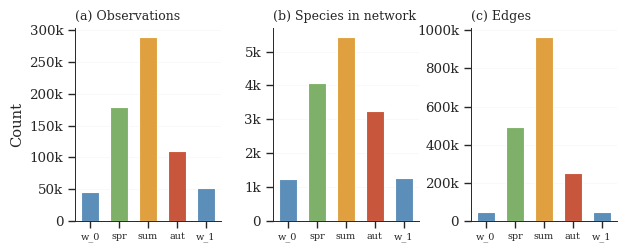

In [ ]:
# ── Plot 1: Seasonal network size comparison ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.5), gridspec_kw={"wspace": 0.35})

x = np.arange(len(SEASONS))
bcolors = [SEASON_PAL[s] for s in SEASONS]

metrics = [
    ("(a) Observations", [seasonal_stats[s]["observations"] for s in SEASONS]),
    ("(b) Species in network", [G_seasonal[s].number_of_nodes() for s in SEASONS]),
    ("(c) Edges", [G_seasonal[s].number_of_edges() for s in SEASONS]),
]

seasons_abbr = ["w_0", "spr", "sum", "aut", "w_1"]

for ax, (title, vals) in zip(axes, metrics):
    bars = ax.bar(x, vals, color=bcolors, edgecolor="white", width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(seasons_abbr, fontsize=7)
    ax.set_title(title, loc="left", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{int(v/1000)}k" if v >= 1000 else f"{int(v)}"))
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Count")
sns.despine()
fig.tight_layout()
savefig(fig, "network_seasonal_size")
plt.show()


C:\Users\trive\AppData\Local\Temp\ipykernel_20980\183146808.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  💾 figures/network_geographic_distribution.png + .pdf


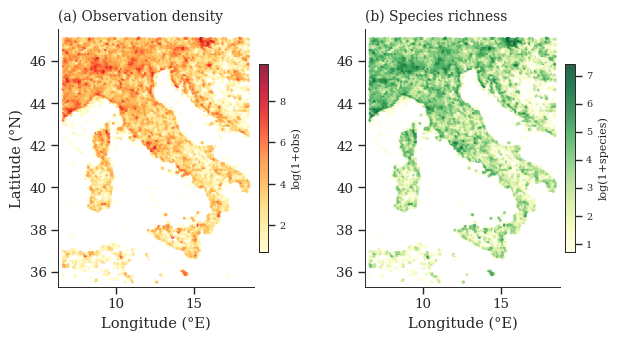

In [9]:
# ── Plot 2: Geographic distribution ───────────────────────────────────────
grid = obs_df.groupby("grid_cell").agg(
    obs_count=("obs_id", "count"),
    species_count=("taxon_id", "nunique"),
    lat=("latitude", "mean"),
    lon=("longitude", "mean"),
).reset_index()

aspect = 1.0 / np.cos(np.radians(42))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 3.5), gridspec_kw={"wspace": 0.30})

for ax, col, cmap, label, title in [
    (ax1, "obs_count", "YlOrRd", "log(1+obs)", "(a) Observation density"),
    (ax2, "species_count", "YlGn", "log(1+species)", "(b) Species richness"),
]:
    sc = ax.scatter(grid["lon"], grid["lat"], c=np.log1p(grid[col]),
                    cmap=cmap, s=5, alpha=0.85, linewidths=0)
    ax.set_xlim(6.3, 18.8); ax.set_ylim(35.3, 47.5)
    ax.set_aspect(aspect)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_xlabel("Longitude (°E)")
    cb = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
    cb.set_label(label, fontsize=8)
    cb.ax.tick_params(labelsize=7)

ax1.set_ylabel("Latitude (°N)")
sns.despine()
fig.tight_layout()
savefig(fig, "network_geographic_distribution")
plt.show()


C:\Users\trive\AppData\Local\Temp\ipykernel_20980\2875671226.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  💾 figures/network_filter_effect.png + .pdf


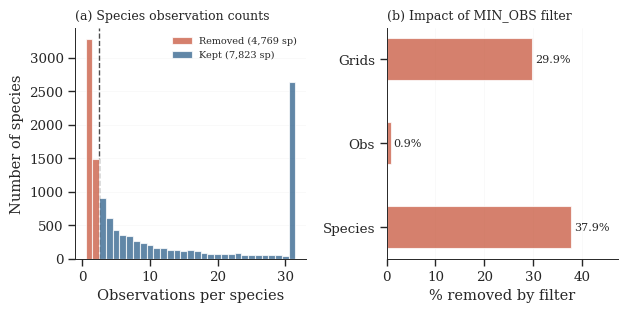


Filter summary: removed 4,769 species (37.9%), but only 0.9% of observations and 29.9% of grid cells.


In [12]:
# ── Plot 3: MIN_OBS filter effect ─────────────────────────────────────────
raw_counts = obs_all["taxon_id"].value_counts()
kept = raw_counts[raw_counts >= MIN_OBS]
removed = raw_counts[raw_counts < MIN_OBS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 3), gridspec_kw={"wspace": 0.35})

# (a) Histogram of observation counts
bins = np.arange(0.5, 32.5, 1)
ax1.hist(removed.values, bins=bins, color="#C7563C", alpha=0.75,
         label=f"Removed ({len(removed):,} sp)", zorder=3)
ax1.hist(kept.values.clip(max=31), bins=bins, color="#2C5F8A", alpha=0.75,
         label=f"Kept ({len(kept):,} sp)", zorder=2)
ax1.axvline(MIN_OBS - 0.5, color="black", ls="--", lw=1, alpha=0.7)
ax1.set_xlabel("Observations per species")
ax1.set_ylabel("Number of species")
ax1.set_title("(a) Species observation counts", loc="left", fontsize=9)
ax1.legend(fontsize=7, frameon=False)
ax1.grid(axis="y", alpha=0.2)

# (b) What % of data is lost
obs_lost = removed.sum()
obs_kept = kept.sum()
cells_removed = obs_all[obs_all["taxon_id"].isin(removed.index)]["grid_cell"].nunique()
cells_total = obs_all["grid_cell"].nunique()

categories = ["Species", "Obs", "Grids"]
pct_removed = [
    len(removed) / (len(kept) + len(removed)) * 100,
    obs_lost / (obs_kept + obs_lost) * 100,
    cells_removed / cells_total * 100,
]
colors = ["#C7563C", "#C7563C", "#C7563C"]

bars = ax2.barh(categories, pct_removed, color="#C7563C", alpha=0.75,
                edgecolor="white", height=0.5)
for bar, pct in zip(bars, pct_removed):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{pct:.1f}%", va="center", fontsize=8)
ax2.set_xlabel("% removed by filter")
ax2.set_title("(b) Impact of MIN_OBS filter", loc="left", fontsize=9)
ax2.set_xlim(0, max(pct_removed) * 1.25)
ax2.grid(axis="x", alpha=0.2)

sns.despine()
fig.tight_layout()
savefig(fig, "network_filter_effect")
plt.show()

print(f"\nFilter summary: removed {len(removed):,} species ({pct_removed[0]:.1f}%), "
      f"but only {pct_removed[1]:.1f}% of observations and {pct_removed[2]:.1f}% of grid cells.")
